**Tarea 3** Regresión lineal y clasificación.

*Introducción a Ciencia de Datos*

***María Guadalupe Villanueva Utrilla***

**Descripción y procedencia de dataset**

El dataset *Wine Quality* empleado para esta primer práctica.
El dataset específico empleado es winequality-red.csv descargado desde la página oficial.




**Estos datos han sido recolectados por UCI Machine Learning Repository**   

(https://archive.ics.uci.edu/dataset/186/wine+quality);

Referencia:

Cortez, P., Cerdeira, A., Almeida, F., Matos, T. y Reis, J. (2009). *Wine Quality*. UCI Machine Learning Repository. DOI: 10.24432/C56S3T.

### Regresión lineal y clasificación

Hay que comparar el uso de una regresión lineal en dos casos distintos: predecir una variable numérica *quality* y después para intentar resolver un problema de clasificación binaria.

Un vino es *bueno* cuando *quality >= 7*.

En esta práctica se usa regresión lineal para observar qué comportamiento tiene este estudio con este dataset.

La partición de los datos estará dada por *80% entrenamiento y 20% prueba*, usando *random_state=42*.


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns                               # gráficas para las estadísticas

from sklearn.model_selection import train_test_split    # para la división de entrenamiento y prueba
from sklearn.linear_model import LinearRegression            # el modelo de regresión lineal
from sklearn.metrics import mean_squared_error, r2_score        # métricas de la regresión
from sklearn.metrics import accuracy_score               # métrica de la clasificación

sns.set_theme(style="whitegrid")

In [22]:
ruta = "winequality-red.csv"                 # archivo de datos de vino tinto
df = pd.read_csv(ruta, sep=";")              # el archivo de UCI usa punto y coma

print("Dimensiones:", df.shape)
display(df.head())

Dimensiones: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Revisión

El dataset iene 1599 registros y 12 columnas. 11 son las características del vino y quality es la variable que se quiere predecir.

In [28]:
print("Tipos de datos:")
print(df.dtypes)

print("\nValores faltantes:")
print(df.isnull().sum())

print("\nFilas duplicadas:", df.duplicated().sum())

Tipos de datos:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Valores faltantes:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Filas duplicadas: 240


### Revisión

Las variables del dataset son de tipo numéricas y no tienen valores faltantes en el archivo. Aparecen algunas filas repetidas porque distintas muestras pueden tener las mismas mediciones

In [29]:
print(df["quality"].describe())               # resumen de la variable objetivo
print("\nFrecuencias de quality:")
print(df["quality"].value_counts().sort_index())

count    1599.000000
mean        5.636023
std         0.807569
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         8.000000
Name: quality, dtype: float64

Frecuencias de quality:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


### Revisión

La calidad no aparece distribuida de manera uniforme. La mayor parte de los vinos se concentra en valores intermedios sobretodo alrededor de los valores 5 y 6, mientras que las calidades más altas son menos frecuentes.

La calidad promedio es de aproximadamente 5.64 y la mediana es 6. Los valores desde de 3 a 8 pero la mayoría de los vinos se están en calidad 5 y 6, con 681 y 638 registros respectivamente.

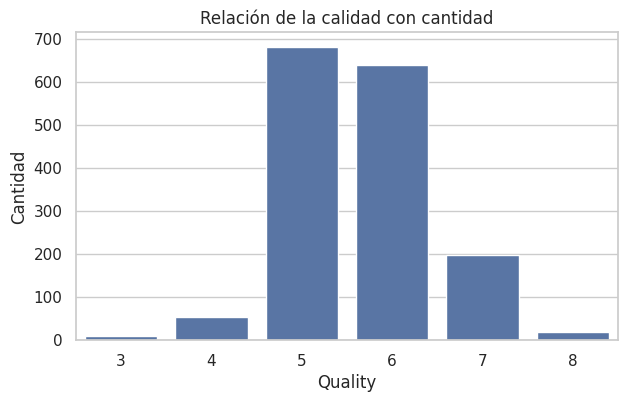

In [31]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="quality")
plt.title("Relación de la calidad con cantidad")
plt.xlabel("Quality")
plt.ylabel("Cantidad")
plt.show()

### Revisión

En la gráfica se puede ver que las clases de calidad no están balanceadas . Hay muchas más observaciones con calidades entre 5 y 6 que con calidades altas o bajas. El porcentaje de aciertos puede verse sesgado por las clases que aparecen con mayor frecuencia

Las calidades altas son pocas: solamente hay 199 vinos con calidad 7 y 18 con calidad 8

In [32]:
corr_quality = df.corr(numeric_only=True)["quality"].sort_values(ascending=False)

print("Correlación con quality:")
print(corr_quality)

Correlación con quality:
quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


### Revisión

Se pueden ver las variables que tienen una mayor relación lineal con *quality*. La correlación puede servir para tener una primera idea de cuáles de las características podrían dar más información a la regresión lineal.

La variable de mayor correlación con la calidad es el alcohol, con  0.48. También, sulphates con 0.25 y citric acid 0.23. Ninguna correlación es muy alta

## 1. Regresión

Se van a utilizar las 11 variables características del vino para predecir un valor numérico de *quality*.

In [42]:
X = df.drop(columns="quality")                                # variables de entrada
y = df["quality"]                                             # variable que queremos predecir

X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.20,                                           # 20/100 para prueba
    random_state=42)                                           # especificado

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (1279, 11)
Prueba: (320, 11)


### Revisión

Se usa la mayoría de los datos para que el modelo aprenda y el 20% restante para evaluarlo con ejemplos que no vio durante el ajuste. Se usa *random_state=42* establecido en los parámetros iniciales de la tarea.

Se tiene 1279 registros para entrenamiento y 320 para prueba y las 11 características.

In [49]:
modelo_reg = LinearRegression()                 # para crear el modelo (lineal)
modelo_reg.fit(X_train, y_train)                # para ajustar el modelo con el entrenamiento

y_pred = modelo_reg.predict(X_test)             # predicciones sobre la prueba

print("Primeras predicciones:", np.round(y_pred[:10], 2))

Primeras predicciones: [5.35 5.06 5.66 5.46 5.73 5.28 5.03 5.13 5.75 5.69]


### Revisión

La regresión devuelve valores continuos, las predicciones tienen incluidos decimales pero la calidad original del dataset está registrada con números enteros pero sí se acerca al valor real.

RMSE de 0.6245, menor que 0.8107 que se obtuvo al predecir el promedio y un R² de 0.4032, el modelo explica cerca del 40% de la variación vista en la calidad

In [62]:
rmse_modelo = np.sqrt(mean_squared_error(y_test, y_pred))    # error cuadrático medio
r2_modelo = r2_score(y_test, y_pred)                         # proporción de variación
promedio_train = y_train.mean()                              # promedio solo del entrenamiento
y_pred_promedio = np.full(len(y_test), promedio_train)       # baseline constante ????
rmse_promedio = np.sqrt(mean_squared_error(y_test, y_pred_promedio))
r2_promedio = r2_score(y_test, y_pred_promedio)

print(f"RMSE regresión lineal: {rmse_modelo:.4f}")
print(f"R² Regresión lineal: {r2_modelo:.4f}")
print()
print(f"RMSE prediciendo siempre el promedio: {rmse_promedio:.4f}")
print(f"R² prediciendo siempre el promedio: {r2_promedio:.4f}")

RMSE regresión lineal: 0.6245
R² Regresión lineal: 0.4032

RMSE prediciendo siempre el promedio: 0.8107
R² prediciendo siempre el promedio: -0.0056


### Revisión

Se ignoran las características del vino y se predice siempre el promedio observado en entrenamiento. La regresión lineal sirve si logra reducir el RMSE respecto a esa referencia y obtener un R² mayor

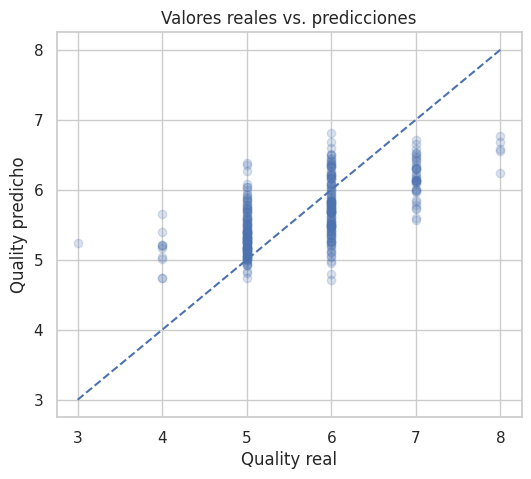

In [68]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.2)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")
plt.xlabel("Quality real")
plt.ylabel("Quality predicho")
plt.title("Valores reales vs. predicciones")
plt.show()

### Revisión

De forma ideal, todos los puntos estarían sobre la línea diagonal. De manera más práctica hay dispersión alrededor de ella, por lo que la regresión captura parte de la tendencia pero no logra explicar por completo la calidad del vino usando solo una relación lineal

El modelo tiende a sobreestimar las calidades bajas y subestimar las altas, el modelo tiene dificultad con los casos extremos

## 2. Clasificación usando la misma regresión lineal

En lugar de predecir el número preciso de calidad, se puede crear una nueva variable:

- **1**: vino bueno, si **quality >= 7**
- **0**: vino no bueno, si **quality < 7**

Después se va a ajustar de nuevo la regresión lineal aunque ahora la variable objetivo solo tendrá valores 0 y 1.

In [75]:
df_clas = df.copy()
df_clas["bueno"] = (df_clas["quality"] >= 7).astype(int)    # para convertir la condición en 0 o 1

print(df_clas["bueno"].value_counts())
print()
print(df_clas["bueno"].value_counts(normalize=True).round(4))

bueno
0    1382
1     217
Name: count, dtype: int64

bueno
0    0.8643
1    0.1357
Name: proportion, dtype: float64


### Revisión

Los vinos buenos representan una parte mucho menor que los vinos no buenos. Entonces conviene comparar el modelo con predecir siempre el que es no bueno. Si el modelo casi no mejora ese porcentaje, entonces su utilidad como clasificador no sería muy adecuada.

Al tener quality >= 7, solo 217 de los 1599 vinos son considerados buenos y 1382 quedan como no buenos

In [77]:
X_clas = df.drop(columns="quality")                          # mismas variables de entrada
y_clas = df_clas["bueno"]                                   # objetivo binario

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clas, y_clas,
    test_size=0.20,
    random_state=42
)

print("Entrenamiento:", X_train_c.shape)
print("Prueba:", X_test_c.shape)
print("Buenos en prueba:", y_test_c.sum())

Entrenamiento: (1279, 11)
Prueba: (320, 11)
Buenos en prueba: 47


### Revisión

Se hace división 80/20 de nuevo con la misma semilla. Ahora lo importante es recordar que la variable objetivo ya no representa una cantidad continua, sino dos categorías: bueno y no bueno.

De los 320 datos de prueba, solamente 47 son vinos buenos, casi todos son no buenos.

In [78]:
modelo_clas_lineal = LinearRegression()                      # la misma regresión lineal
modelo_clas_lineal.fit(X_train_c, y_train_c)                 # para ajustar valores 0 y 1

y_score = modelo_clas_lineal.predict(X_test_c)               # salidas continuas
y_pred_clas = (y_score >= 0.5).astype(int)                   # umbral solicitado

print("Primeras salidas:", np.round(y_score[:10], 3))
print("Primeras clases:", y_pred_clas[:10])

Primeras salidas: [ 0.    -0.049  0.112  0.005  0.149 -0.048 -0.047 -0.011  0.165  0.139]
Primeras clases: [0 0 0 0 0 0 0 0 0 0]


### Revisión

Se tiene que el objetivo solo contiene 0 y 1, perola regresión lineal sigue dando cualquier valor real. Para transformarlo en una clase se hace de forma manual el umbral de 0.5: valores mayores o iguales se consideran "buenos" y los demás "no buenos".


In [88]:
accuracy_modelo = accuracy_score(y_test_c, y_pred_clas)      # porcentaje de aciertos
pred_siempre_no = np.zeros(len(y_test_c), dtype=int)         # baseline: siempre malo (o no bueno)
accuracy_no_bueno = accuracy_score(y_test_c, pred_siempre_no)
fuera_rango = np.sum((y_score < 0) | (y_score > 1))          # salidas no posibles como probabilidad

print(f"Accuracy regresión usada como clasificador: {accuracy_modelo:.4f}")
print(f"Porcentaje de aciertos: {accuracy_modelo * 100:.2f}%")
print()
print(f"Accuracy prediciendo siempre malo (o no bueno): {accuracy_no_bueno:.4f}")
print(f"Porcentaje siempre malo (o no bueno): {accuracy_no_bueno * 100:.2f}%")
print()
print(f"Predicciones fuera de [0, 1]: {fuera_rango} de {len(y_score)}")

Accuracy regresión usada como clasificador: 0.8625
Porcentaje de aciertos: 86.25%

Accuracy prediciendo siempre malo (o no bueno): 0.8531
Porcentaje siempre malo (o no bueno): 85.31%

Predicciones fuera de [0, 1]: 82 de 320


### Revisión

La comparación con "siempre no bueno" nos deja ver cuánto aporta el modelo en un conjunto no balanceado. También contar las predicciones menores que 0 o mayores que 1 da una limitación directa de la regresión lineal, que las salidas no se restringen al intervalo de una probabilidad. La recta no es pero no es una elección muy adecuada para una clasificación de tipo binaria

El modelo llega a un 86.25% de accuracy, pero predecir siempre el no bueno ya tiene de por sí 85.31% debido al desbalance de las clases. La regresión solamente mejora alrededor de 0.94

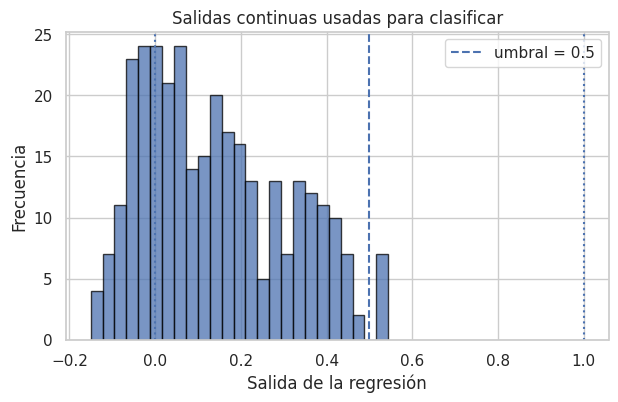

In [98]:
plt.figure(figsize=(7, 4))
plt.hist(y_score, bins=25, edgecolor="black", alpha=0.75)
plt.axvline(0.5, linestyle="--", label="umbral = 0.5")
plt.axvline(0, linestyle=":")
plt.axvline(1, linestyle=":")
plt.xlabel("Salida de la regresión")
plt.ylabel("Frecuencia")
plt.title("Salidas continuas usadas para clasificar")
plt.legend()
plt.show()

### Revisión

EL modelo no genera clases como tal solo valores continuos. El umbral que se hizo de 0.5 separa de manera forzada a las dos decisiones y las líneas de 0 y 1 muestran el intervalo que se podría esperar si las salidas se interpretaran como probabilidades

De las 320 predicciones, 82 quedaron fuera del intervalo, por lo que que una regresión lineal no da probabilidades válidas de forma natural

## Conclusión

En la regresión el objetivo es aproximar un valor numérico de calidad, por lo que una salida continua tiene sentido y el desempeño del modelo se puede medir con RMSE y R². En clasificación el objetivo cambia a decidir entre dos categorías y entonces se necesita convertir la salida continua en una clase mediante un umbral. El problema que se nota de usar una regresión lineal como un clasificador es que la recta no se limita entre 0 y 1 y da valores sin sentido si son vistos como probabilidades. Además, el umbral de 0.5 se agrega de forma externa y forzada en el modelo. Para un problema binario se necesitaría utilizar un modelo como que su salida sí entre al intervalo entre 0 y 1.

**Declaración sobre el uso de inteligencia artificial**

Para la realización de esta práctica se utilizó *Gemini (Google AI*) como herramienta de soporte técnico, pedagógico y de redacción.
Alcance de uso:
* Soporte de código y resolución de errores
* Comprensión de licencias.
* Supervisión de formato de texto.
* Supervisión y sugerencia de cómo hacer la separación binaria y cómo insertar de forma manual un 0.5 para hacer una 'clasificación'.


